
# 📉 **Método del Codo para Determinar el Número Óptimo de Clusters**


### 🧠 **Introducción**

El **método del codo (Elbow Method)** es una técnica visual ampliamente utilizada para determinar el **número óptimo de clusters (K)** en algoritmos de agrupamiento como **K-Means**.  
Su idea principal es analizar cómo cambia el **costo de compactación** (también conocido como *inercia* o *suma de distancias cuadradas dentro de los clusters*) conforme aumenta el número de clusters.

📊 En general:
- A medida que aumenta \(K\), la inercia disminuye (los clusters son más pequeños y ajustados).  
- Sin embargo, **después de cierto punto**, la mejora es marginal: ese punto se conoce como el **"codo"** de la gráfica.

### ⚙️ **Fórmula de la inercia**

$$J = \sum_{i=1}^{K} \sum_{x_j \in C_i} ||x_j - \mu_i||^2$$

Donde:
- $C_i$: conjunto de puntos en el cluster $i$
- $\mu_i$: centroide del cluster $i$
- $J$: suma total de distancias cuadradas (inercia)

In [ ]:
import pandas as pd

In [ ]:
pd.read_csv('sample_data/california_housing_test.csv').columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


### 📦 **Generación de datos de ejemplo**


Usaremos `make_blobs` para crear un dataset sintético con tres agrupaciones naturales.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


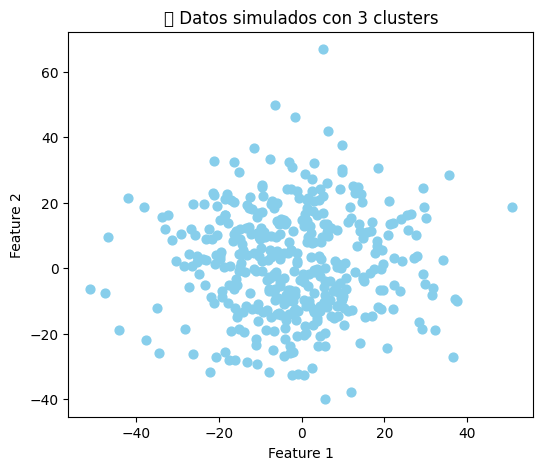

In [ ]:

from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Crear datos de ejemplo
X, y = make_blobs(n_samples=400, centers=3, cluster_std=15, random_state=42)

# Visualizar los datos
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c='skyblue', s=40)
plt.title("🌸 Datos simulados con 3 clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()



### 🔢 **Cálculo de la inercia para distintos valores de K**


Calcularemos la **inercia** del modelo K-Means para valores de K entre 1 y 10.

In [ ]:

from sklearn.cluster import KMeans

inertias = []
K_values = range(1, 20)

for k in K_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

inertias


[29190.411378598008,
 10205.338880244215,
 3058.7999883295406,
 2671.1373220735445,
 2300.628633052954,
 1954.1320842072712,
 1715.8788647627173,
 1518.6904247295415,
 1314.6625984280604,
 1225.9951428621832,
 1128.80027575676,
 1044.681144140819,
 988.3494084233286,
 904.5756012759333,
 842.7643824798441,
 782.4216537055854,
 730.1739330165811,
 701.4426863925685,
 651.5499330663947]


### 📈 **Visualización del método del codo**


Calcularemos la **inercia** del modelo K-Means para valores de K entre 1 y 10.

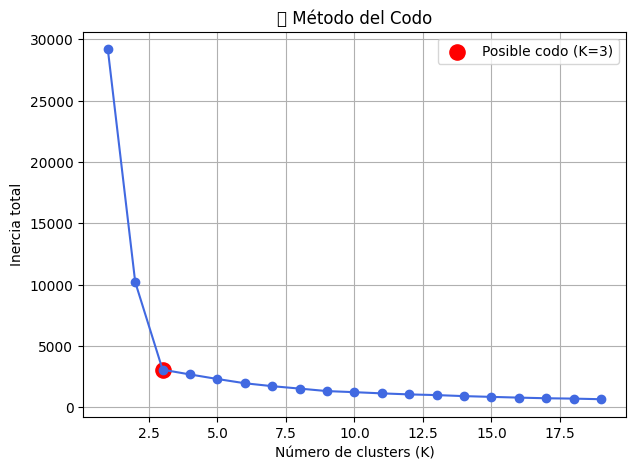

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(K_values, inertias, marker='o', color='royalblue')
plt.scatter(3, inertias[2], color='red', s=120, label='Posible codo (K=3)')
plt.title("📉 Método del Codo")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia total")
plt.legend()
plt.grid(True)
plt.show()



### 🧭 **Conclusión**
✅ El **método del codo** nos ayuda a elegir el número adecuado de clusters observando el punto donde la reducción de inercia **deja de ser significativa**.  
En este caso, el "codo" aparece cerca de **K = 3**, que coincide con el número real de agrupaciones generadas.

💡 Puede complementarse con otros métodos como el **índice de silueta** o el **Gap Statistic** para mayor robustez.
